# Mixed Human and Autonomous Traffic Resilience

This notebook communicates the computational investigation using the generated results already committed in `results/`. It is intended to support our code, report, and demonstration components; it does not rerun the long experiments or alter project files.

**Research question.** How do autonomous-vehicle penetration and controller strategy affect the severity and recovery of braking-induced congestion, and how does safe two-lane passing alter this response?

The model is an exploratory discrete circular-road model. Speeds, distances, and times are model units, not calibrated real-world quantities.

## 1. Starting point: a simple baseline

We began with the simplest useful question: what happens on a circular road when vehicles follow the same safe-gap rule but human drivers sometimes slow down? This is a deliberately small model, so we can understand the update rule and test it before adding AVs, extra lanes, or a braking event.

The project then develops in stages:

1. compare human-only, mixed, and AV-only traffic;
2. repeat conditions with multiple seeds instead of relying on one run;
3. introduce reactive and anticipatory AV controllers;
4. apply a controlled braking shock and measure recovery;
5. check whether the pattern changes with two lanes or more unpredictable human slowing.

This order is important: each extension answers a limitation or question raised by the previous stage.

## Contribution beyond the taught baseline

A one-lane ring-road traffic jam is used as a controlled baseline because traffic jams are a taught CITS4403 example. The project contribution is the systematic resilience study built around that baseline: mixed human/AV populations, reactive versus anticipatory AV rules, a controlled braking intervention with matched no-shock controls, safe two-lane passing, repeated random seeds, recovery metrics, and human-driver slowdown sensitivity. These extensions are the basis for the claims below.

## 2. What the model represents

### Model specification and assumptions

* The road is a one- or two-lane circular cellular automaton with synchronous updates.
* Each vehicle occupies one cell and has an integer speed between zero and the speed limit.
* Vehicles accelerate by one and brake to the available forward gap. Human vehicles additionally slow randomly with probability 0.2 by default.
* Reactive AVs use the safe gap; anticipatory AVs also account for the speed of the vehicle ahead and a safety buffer.
* On two lanes, a vehicle changes lane only when the target cell is empty, the target forward gap is larger, and the look-back safety condition is satisfied.
* Initial positions, vehicle types, and human stochastic decisions are controlled by a recorded seed.
* The braking shock caps vehicle 0 at speed zero for eight measurement steps. Recovery is the first 20-step post-shock window reaching 95% of the pre-shock mean speed.

These assumptions make the mechanism transparent but limit external validity: there are no junctions, arrivals, departures, calibration, reaction delays, or communication failures.

In [1]:
from pathlib import Path
import csv
from statistics import mean, stdev

# Works when launched from the repository root or from notebooks/.
here = Path.cwd()
ROOT = here if (here / 'results').exists() else here.parent
RESULTS = ROOT / 'results'

def read_csv(name):
    with (RESULTS / name).open(newline='', encoding='utf-8') as f:
        return list(csv.DictReader(f))

final_summary = read_csv('final-summary.csv')
shock_summary = read_csv('shock-recovery-summary.csv')
slowdown = read_csv('slowdown-sensitivity.csv')
shock_timeseries = read_csv('shock-recovery-timeseries.csv')
print('Repository:', ROOT)
print('Rows:', len(final_summary), len(shock_summary), len(slowdown), len(shock_timeseries))

Repository: c:\Users\adria\Downloads\mixed-autonomous-human-traffic-simulation
Rows: 18 36 15 14400


## 3. Checking the data before interpreting it

Before making a claim, we check that the files contain the experiment we think they contain. The counts below are a simple reproducibility check: they should match the design described in the experiment scripts and README.

## Experimental design and reproducibility

The steady-state matrix contains 3 densities × 6 requested AV shares × 20 seeds = 360 runs. The shock matrix contains 360 paired disturbed/control runs across densities, lane counts, policies, AV shares, and 10 seeds. The slowdown sensitivity matrix contains 15 aggregated conditions from 10 seeds each. Summary files report means and seed-level standard deviations; this separates uncertainty across independent runs from within-run speed variation.

In [2]:
def f(row, key):
    return float(row[key]) if row[key] not in ('', 'None', 'nan') else None

print('Steady-state conditions:', len(final_summary), 'expected 18')
print('Shock conditions:', len(shock_summary), 'expected 36')
print('Slowdown conditions:', len(slowdown), 'expected 15')
print('\nSelected steady-state rows:')
for row in final_summary:
    if row['density'] == '0.2' and row['requested_av_share'] in ('0.0', '0.5', '1.0'):
        print({k: row[k] for k in ('density', 'requested_av_share', 'num_runs', 'mean_speed_mean', 'stopped_fraction_mean')})

Steady-state conditions: 18 expected 18
Shock conditions: 36 expected 36
Slowdown conditions: 15 expected 15

Selected steady-state rows:
{'density': '0.2', 'requested_av_share': '0.0', 'num_runs': '20', 'mean_speed_mean': '2.6484734375', 'stopped_fraction_mean': '0.2027015625'}
{'density': '0.2', 'requested_av_share': '0.5', 'num_runs': '20', 'mean_speed_mean': '3.1758265625', 'stopped_fraction_mean': '0.1397046875'}
{'density': '0.2', 'requested_av_share': '1.0', 'num_runs': '20', 'mean_speed_mean': '4.0', 'stopped_fraction_mean': '0.00625'}


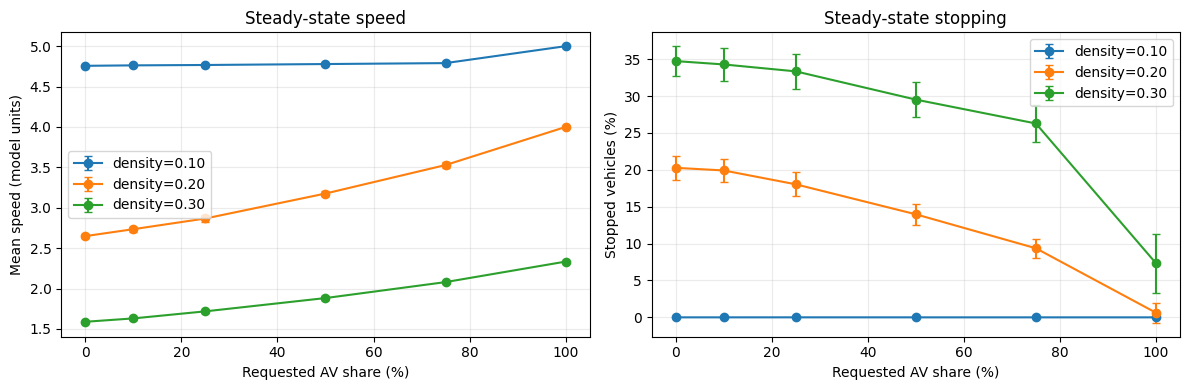

In [3]:
try:
    import matplotlib.pyplot as plt
    plotting_available = True
except ImportError:
    plotting_available = False
    print('matplotlib is not installed; numerical analysis cells remain usable.')

if plotting_available:
    densities = sorted({f(r, 'density') for r in final_summary})
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for density in densities:
        rows = sorted((r for r in final_summary if f(r, 'density') == density), key=lambda r: f(r, 'requested_av_share'))
        x = [100 * f(r, 'requested_av_share') for r in rows]
        axes[0].errorbar(x, [f(r, 'mean_speed_mean') for r in rows], yerr=[f(r, 'mean_speed_seed_sd') for r in rows], marker='o', capsize=3, label=f'density={density:.2f}')
        axes[1].errorbar(x, [100 * f(r, 'stopped_fraction_mean') for r in rows], yerr=[100 * f(r, 'stopped_fraction_seed_sd') for r in rows], marker='o', capsize=3, label=f'density={density:.2f}')
    axes[0].set(xlabel='Requested AV share (%)', ylabel='Mean speed (model units)', title='Steady-state speed')
    axes[1].set(xlabel='Requested AV share (%)', ylabel='Stopped vehicles (%)', title='Steady-state stopping')
    for ax in axes:
        ax.grid(alpha=.25)
        ax.legend()
    fig.tight_layout()
    plt.show()

### First result: steady-state traffic

Read this figure from left to right. At each density, increasing AV share generally raises mean speed and lowers the stopped fraction in this model. The density curves are separated because the same AV intervention can have a different effect when the road is already crowded. Error bars show variation between seeds, not measurement error from real traffic.

A useful student-level conclusion at this stage is not that AVs always solve congestion, but that the model predicts a density-dependent association that should be tested under a disturbance.

### Shock-recovery evidence

The next plot compares the maximum stopped fraction during the braking event and the mean recovery time. Conditions are grouped by lane count and AV policy. A missing recovery time means the 95% threshold was not reached during the measured period; it should not be silently interpreted as zero.

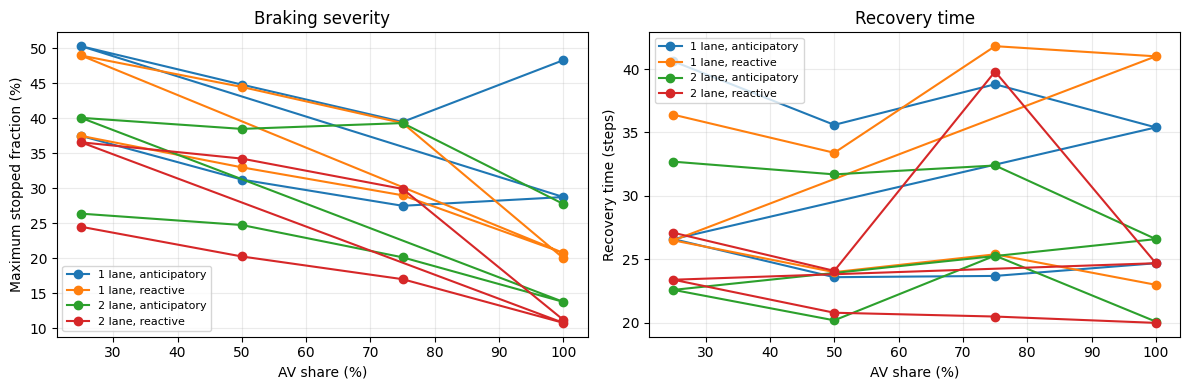

In [4]:
if plotting_available:
    groups = sorted({(int(r['lanes']), r['av_policy']) for r in shock_summary})
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for lanes, policy in groups:
        rows = sorted((r for r in shock_summary if int(r['lanes']) == lanes and r['av_policy'] == policy and r['requested_av_share'] != '0.0'), key=lambda r: (f(r, 'density'), f(r, 'requested_av_share')))
        label = f'{lanes} lane, {policy}'
        x = [100 * f(r, 'requested_av_share') for r in rows]
        y = [100 * f(r, 'maximum_stopped_fraction_after_braking_mean') for r in rows]
        recovery = [f(r, 'recovery_time_steps_mean') if f(r, 'recovery_time_steps_mean') is not None else float('nan') for r in rows]
        axes[0].plot(x, y, marker='o', label=label)
        axes[1].plot(x, recovery, marker='o', label=label)
    axes[0].set(xlabel='AV share (%)', ylabel='Maximum stopped fraction (%)', title='Braking severity')
    axes[1].set(xlabel='AV share (%)', ylabel='Recovery time (steps)', title='Recovery time')
    for ax in axes:
        ax.grid(alpha=.25)
        ax.legend(fontsize=8)
    fig.tight_layout()
    plt.show()

### Second result: response to a braking event

The shock experiment changes the question from average performance to resilience. We compare the same initial condition with and without the braking cap, then report the size of the disruption and the time needed to return near the pre-shock speed. The two-lane comparison is designed to keep occupancy density equal, so it is not simply a comparison of more vehicles with fewer vehicles.

When reading this plot, distinguish a lower peak stopped fraction from a faster recovery: they are related but different outcomes. Also remember that recovery is defined by an arbitrary, explicit 95% threshold in model units.

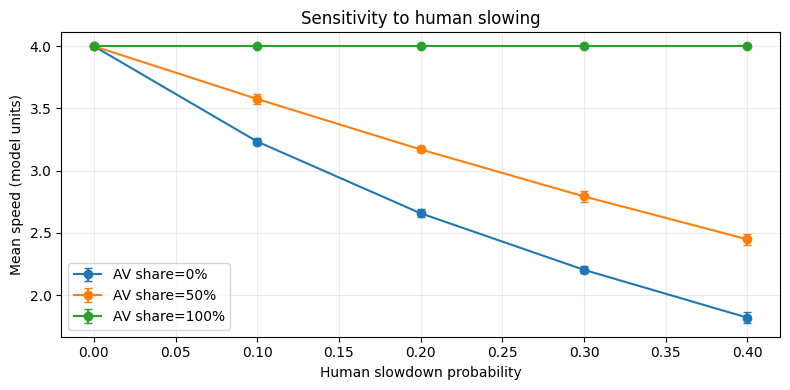

In [5]:
if plotting_available:
    fig, ax = plt.subplots(figsize=(8, 4))
    for av_share in sorted({f(r, 'av_share') for r in slowdown}):
        rows = sorted((r for r in slowdown if f(r, 'av_share') == av_share), key=lambda r: f(r, 'human_slow_prob'))
        ax.errorbar([f(r, 'human_slow_prob') for r in rows], [f(r, 'mean_speed_mean') for r in rows], yerr=[f(r, 'mean_speed_sd') for r in rows], marker='o', capsize=3, label=f'AV share={av_share:.0%}')
    ax.set(xlabel='Human slowdown probability', ylabel='Mean speed (model units)', title='Sensitivity to human slowing')
    ax.grid(alpha=.25)
    ax.legend()
    fig.tight_layout()
    plt.show()

### Third result: sensitivity to human behaviour

Finally, we vary the human slowdown probability. This is a sensitivity analysis rather than a claim that 0.0--0.4 spans realistic driver behaviour. If the qualitative AV pattern changes substantially across this range, the conclusion is sensitive to a modelling assumption and should be reported cautiously.

## Interpretation, limitations, and conclusions

Use the plots and tables to answer the research question rather than treating a visual trend as proof of a universal traffic effect. The design supports cautious within-model comparisons of AV share, controller rule, lanes, and human slowdown probability under fixed occupancy and reproducible shocks. It does not establish that AVs improve real traffic, because the AV rules are deliberately idealised and the road geometry is highly simplified.

Important limitations are the single circular topology, abstract cell and time units, perfect AV sensing, deterministic AV behaviour, simplified passing, fixed shock location and duration, and finite seed counts. Useful extensions would include heterogeneous reaction delays, imperfect sensing/communication, inflow and outflow boundaries, calibrated parameters, and confidence intervals or formal effect-size tests. The matched control design and repeated seeds are strengths, but the experiment should not claim more precision than the model supports.